# Telecom Customer Churn Prediction

## Business Objective
A telecom company wants to identify customers who are likely to leave so that proactive retention offers can be provided.

This notebook:
- Loads and understands the customer churn dataset.
- Selects relevant customer attributes.
- Cleans and preprocesses the data.
- Builds a Logistic Regression classification model.
- Estimates the probability that a customer will churn.
- Classifies customers as **Likely to Churn** or **Likely to Stay**.
- Predicts churn for unseen customer records.
- Evaluates the model using accuracy, precision, recall, F1-score, ROC-AUC, and a confusion matrix.
- Interprets the results in business terms.

## 1. Import Libraries

In [1]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

## 2. Load the Dataset

In [2]:
# The uploaded archive contains the Telco Customer Churn CSV.
# If archive.zip is present, extract it. Otherwise, look for the CSV directly.

zip_path = "archive.zip"
csv_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(".")

dataset = pd.read_csv(csv_name)

print("Dataset shape:", dataset.shape)
dataset.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Understand the Customer Attributes

In [3]:
print("Columns:")
print(dataset.columns.tolist())

print("\nData types:")
print(dataset.dtypes)

print("\nMissing values:")
print(dataset.isnull().sum())

print("\nChurn distribution:")
print(dataset["Churn"].value_counts())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender       

### Important attributes

Relevant inputs include:
- **SeniorCitizen** – whether the customer is a senior citizen.
- **Partner, Dependents** – customer family information.
- **tenure** – number of months the customer has stayed.
- **PhoneService, MultipleLines** – phone service details.
- **InternetService** – type of internet service.
- **OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport** – additional services.
- **StreamingTV, StreamingMovies** – streaming services.
- **Contract** – contract type.
- **PaperlessBilling, PaymentMethod** – billing and payment information.
- **MonthlyCharges, TotalCharges** – customer spending information.

`customerID` is excluded because it is an identifier and should not be used as a predictive feature.
`Churn` is the target variable.

## 4. Prepare the Data

In [4]:
data = dataset.copy()

# TotalCharges is stored as text in the original dataset.
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Separate input features and target.
X = data.drop(columns=["Churn", "customerID"])
y = data["Churn"].map({"No": 0, "Yes": 1})

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)
print("Churn rate:", round(y.mean() * 100, 2), "%")

Input feature shape: (7043, 19)
Target shape: (7043,)
Churn rate: 26.54 %


## 5. Split Data into Training and Testing Sets

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 5634
Testing records: 1409


## 6. Preprocess Numerical and Categorical Features

In [6]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(exclude=["object"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Build the Churn Prediction Model

In [7]:
# class_weight="balanced" gives more importance to the churn class,
# helping the model identify more customers who are likely to leave.

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 8. Predict Churn for Unseen Test Customers

In [8]:
y_pred = model.predict(X_test)
churn_probability = model.predict_proba(X_test)[:, 1]

prediction_results = X_test.copy()
prediction_results["Actual_Churn"] = y_test.map({0: "No", 1: "Yes"}).values
prediction_results["Churn_Probability"] = churn_probability
prediction_results["Prediction"] = np.where(
    y_pred == 1,
    "Likely to Churn",
    "Likely to Stay"
)

prediction_results.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Churn_Probability,Prediction
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20,No,0.115472,Likely to Stay
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No,0.853079,Likely to Churn
2235,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20,No,0.146831,Likely to Stay
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75,No,0.660663,Likely to Churn
3761,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35,No,0.060436,Likely to Stay
5748,Female,0,No,No,21,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),99.85,1992.55,No,0.806060,Likely to Churn
3568,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,No,Yes,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),99.15,1956.40,No,0.698471,Likely to Churn
2976,Male,0,No,Yes,19,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),24.10,439.20,No,0.294135,Likely to Stay
5928,Female,0,Yes,Yes,61,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.75,1311.60,No,0.009293,Likely to Stay
1639,Male,1,No,No,17,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.05,770.60,Yes,0.652555,Likely to Churn


## 9. Evaluate Model Performance

In [9]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, churn_probability)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Stayed", "Churned"]
))

Accuracy : 0.7381
Precision: 0.5043
Recall   : 0.7834
F1-Score : 0.6136
ROC-AUC  : 0.8413

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.72      0.80      1035
     Churned       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## 10. Confusion Matrix

Confusion Matrix:
[[747 288]
 [ 81 293]]

True Negatives (correctly identified non-churn): 747
False Positives (non-churn customers incorrectly flagged as churn): 288
False Negatives (churn customers missed by the model): 81
True Positives (churn customers correctly identified): 293


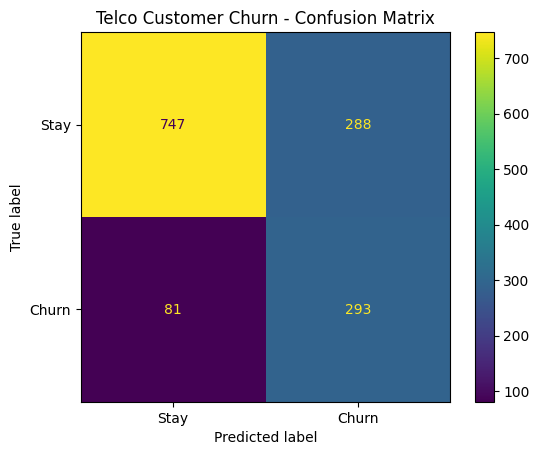

In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives (correctly identified non-churn):", tn)
print("False Positives (non-churn customers incorrectly flagged as churn):", fp)
print("False Negatives (churn customers missed by the model):", fn)
print("True Positives (churn customers correctly identified):", tp)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Churn"]
).plot()

plt.title("Telco Customer Churn - Confusion Matrix")
plt.show()

## 11. Business Interpretation

For this test set, the model correctly identifies **293 customers who actually churned**.

It incorrectly flags **288 customers who actually stayed** as likely to churn.

The model also misses **81 customers who actually churned**.

### Which mistake is more costly?

In most telecom retention situations, **missing a customer who is actually going to leave (False Negative)** is more costly than wrongly flagging a loyal customer (False Positive).

Why?
- A missed churner may leave without receiving a retention offer.
- The company loses recurring revenue.
- Acquiring a replacement customer can cost more than retaining an existing customer.

A false positive can also have a cost because the company may give a retention discount to someone who would have stayed anyway. However, if retention offers are relatively inexpensive, accepting some false positives can be worthwhile to reduce missed churners.

Therefore, the business should usually prioritize **high recall for the churn class**, while controlling the cost of unnecessary offers.

## 12. Example: Predict an Unseen Customer

In [11]:
# Take one customer from the test set as an example of an unseen record.
new_customer = X_test.iloc[[0]].copy()

probability = model.predict_proba(new_customer)[0, 1]
prediction = "Likely to Churn" if probability >= 0.50 else "Likely to Stay"

print("Churn Probability:", round(probability, 4))
print("Prediction:", prediction)
display(new_customer)

Churn Probability: 0.1155
Prediction: Likely to Stay


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2


## 13. One Improvement to Make the Prediction More Reliable

A useful improvement is **threshold tuning**.

The default classification threshold is 0.50. Since missing a customer who will churn can be expensive, the company can lower the threshold (for example, after validation) so more high-risk customers are identified.

This would generally increase recall, although it may also increase false positives.

Another strong improvement would be to compare Logistic Regression with models such as Random Forest or Gradient Boosting and select the model using cross-validation and business-focused metrics.

## 14. Final Conclusion

The Logistic Regression model provides a practical baseline for telecom churn prediction.

For the test data:
- **293 churn customers were correctly identified.**
- **288 non-churn customers were incorrectly flagged as churn.**
- **81 actual churn customers were missed.**
- **Recall for churn = approximately 78.34%.**
- **ROC-AUC = approximately 84.13%.**

The model can therefore support a retention strategy by assigning each customer a churn probability and prioritizing customers with higher predicted risk for proactive retention offers.